# Mini Project — Exploratory Data Analysis on India's COVID-19 Data

State-wise trends, recovery rates, and vaccination progress.

**Module 1: Python for Data Science** — Pandas, NumPy, Matplotlib, Seaborn.

## Step 1 — Load the data

Both datasets are read directly from their public GitHub / OWID URLs with `pandas.read_csv()`
— no manual download required.

In [1]:
import pandas as pd

In [2]:
cases = pd.read_csv(
    "https://raw.githubusercontent.com/imdevskp/"
    "covid-19-india-data/master/complete.csv"
)
vax = pd.read_csv(
    "https://raw.githubusercontent.com/owid/covid-19-data/master/"
    "public/data/vaccinations/country_data/India.csv"
)

print("cases:", cases.shape)
print("vax:  ", vax.shape)

cases: (4692, 10)
vax:   (1250, 8)


## Step 2 — Inspect before touching anything

Look at the raw data *before* cleaning or plotting anything. Each check gets its own cell so no
output is swallowed — a notebook only displays the last expression in a cell.

In [3]:
cases.dtypes

Date                          object
Name of State / UT            object
Latitude                     float64
Longitude                    float64
Total Confirmed cases        float64
Death                         object
Cured/Discharged/Migrated    float64
New cases                      int64
New deaths                     int64
New recovered                  int64
dtype: object

In [4]:
cases.isna().sum()

Date                         0
Name of State / UT           0
Latitude                     0
Longitude                    0
Total Confirmed cases        0
Death                        0
Cured/Discharged/Migrated    0
New cases                    0
New deaths                   0
New recovered                0
dtype: int64

In [5]:
cases["Name of State / UT"].nunique()

40

In [6]:
sorted(cases["Name of State / UT"].unique())[:12]

['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana']

### What the inspection reveals

Two real-world data problems show up immediately:

1. **The `Death` column is stored as text (`object`), not a number.** It can't be summed or
   compared until it is converted.
2. **The same state is spelled multiple ways** — `Telangana`, `Telengana`, and `Telangana***`
   are all one state, and some Union Territories appear twice (once plain, once prefixed with
   `"Union Territory of ..."`). That is why the raw state count is **40** rather than the true 35.

## Step 3 — Clean

Rename columns to short lowercase names, fix the text-typed death counts, collapse the duplicate
state spellings, drop duplicate (date, state) rows, and derive an `active` cases column.

> **Key idea:** Clean once, at the start, before any grouping or plotting. If you fix a spelling
> mistake *after* you've already run a `groupby("state")`, every chart before that point is
> silently wrong.

In [7]:
cases.columns = [
    "date", "state", "lat", "long", "confirmed",
    "deaths", "cured", "new_cases", "new_deaths", "new_recovered",
]
cases["date"] = pd.to_datetime(cases["date"])
cases["deaths"] = pd.to_numeric(cases["deaths"], errors="coerce").fillna(0).astype(int)

name_fix = {
    "Telangana***": "Telangana",
    "Telengana": "Telangana",
    "Union Territory of Jammu and Kashmir": "Jammu and Kashmir",
    "Union Territory of Ladakh": "Ladakh",
    "Union Territory of Chandigarh": "Chandigarh",
}
cases["state"] = cases["state"].replace(name_fix)
cases = cases.drop_duplicates(subset=["date", "state"])
cases["active"] = cases["confirmed"] - cases["deaths"] - cases["cured"]

### Confirming the clean worked

The state count should now be 35, and `deaths` should be an integer column.

In [8]:
print("states after cleaning:", cases["state"].nunique())
print("days covered:        ", cases["date"].nunique())
print("date range:          ", cases["date"].min().date(), "to", cases["date"].max().date())
print("deaths dtype:        ", cases["deaths"].dtype)
print("missing values left: ", int(cases[["confirmed", "deaths", "cured"]].isna().sum().sum()))

states after cleaning: 35
days covered:         186
date range:           2020-01-30 to 2020-08-06
deaths dtype:         int64
missing values left:  0


## Step 4 — Explore with `groupby` and `pivot_table`

Three reshapes drive every chart that follows:

- `national` — daily country-wide totals, plus a national recovery rate.
- `latest` — the single most recent day, one row per state, sorted by case count.
- `pivot` — new cases by state (rows) and month (columns).

In [9]:
# National daily totals
national = cases.groupby("date", as_index=False)[
    ["confirmed", "deaths", "cured"]
].sum()
national["recovery_rate"] = (national["cured"] / national["confirmed"] * 100).round(2)

# Latest snapshot per state, sorted
latest = cases[cases["date"] == cases["date"].max()]
latest = latest.sort_values("confirmed", ascending=False)

# Case growth by state and month
cases["month"] = cases["date"].dt.strftime("%Y-%m")
pivot = cases.pivot_table(
    values="new_cases", index="state", columns="month", aggfunc="sum", fill_value=0
)

### The national picture at the end of the window

In [10]:
national.tail()

,date,confirmed,deaths,cured,recovery_rate
181,2020-08-02,1750723.0,37364,1145629.0,65.44
182,2020-08-03,1803695.0,38135,1186203.0,65.77
183,2020-08-04,1855745.0,38938,1230509.0,66.31
184,2020-08-05,1908254.0,39795,1282215.0,67.19
185,2020-08-06,1964536.0,40699,1328336.0,67.62


### Where each state stood on the final day

`active = confirmed - deaths - cured`, the cases still open on that date.

In [11]:
latest[["state", "confirmed", "cured", "deaths", "active"]].head(10)

,state,confirmed,cured,deaths,active
4676,Maharashtra,468265.0,305521.0,16476,146268.0
4686,Tamil Nadu,273460.0,214815.0,4461,54184.0
4658,Andhra Pradesh,186461.0,104354.0,1681,80426.0
4672,Karnataka,151449.0,74679.0,2804,73966.0
4665,Delhi,140232.0,126116.0,4044,10072.0
4689,Uttar Pradesh,104388.0,60558.0,1857,41973.0
4691,West Bengal,83800.0,58962.0,1846,22992.0
4687,Telangana,73050.0,52103.0,589,20358.0
4667,Gujarat,66669.0,49433.0,2556,14680.0
4661,Bihar,64770.0,42414.0,355,22001.0


### The month-by-month pivot table

Rows are states, columns are months, values are new cases recorded that month. Reading across a
row shows how that state's outbreak accelerated.

In [12]:
pivot.loc[latest["state"].head(8)]

month,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08
state,,,,,,,,
Maharashtra,0,0,218,9699,55253,104715,241915,56467
Tamil Nadu,0,0,73,2088,19022,65040,153754,33482
Andhra Pradesh,0,0,39,1292,2237,10322,116666,55904
Karnataka,0,0,82,452,2387,11373,104337,32817
Delhi,0,0,96,3342,15110,66612,49242,5829
Uttar Pradesh,0,0,95,2033,5311,15383,58211,23349
West Bengal,0,0,25,732,4372,12777,49785,16108
Telangana,0,0,78,933,1487,12686,45323,12333


## Step 5 — Visualise

Twelve charts built with Matplotlib and Seaborn.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### National trends over time

**Figure 1** — Cumulative confirmed cases, recoveries, and deaths, nationally.

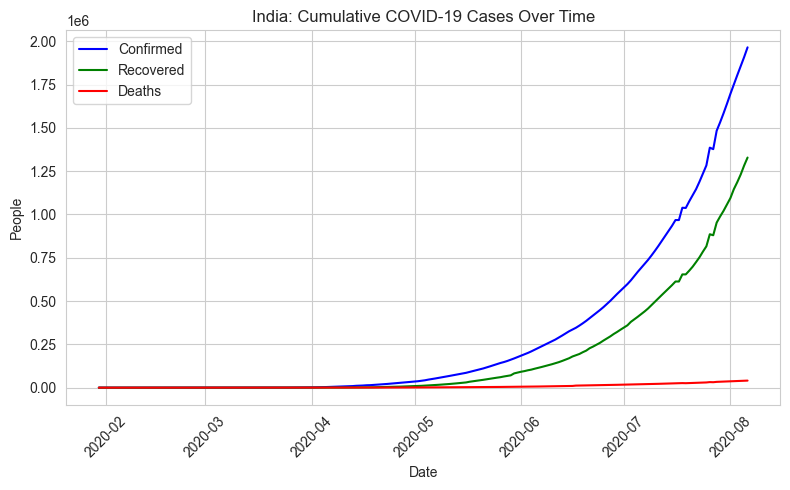

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(national["date"], national["confirmed"], label="Confirmed", color="blue")
plt.plot(national["date"], national["cured"], label="Recovered", color="green")
plt.plot(national["date"], national["deaths"], label="Deaths", color="red")
plt.title("India: Cumulative COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("People")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figure 2** — Daily new confirmed cases, nationally.

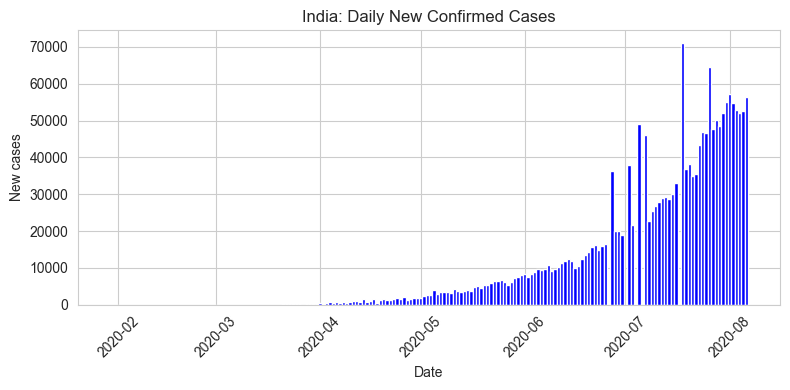

peak daily new cases: 70962 on 2020-07-18


In [15]:
daily_new = cases.groupby("date", as_index=False)["new_cases"].sum()

plt.figure(figsize=(8, 4))
plt.bar(daily_new["date"], daily_new["new_cases"], color="blue", width=1)
plt.title("India: Daily New Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("New cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("peak daily new cases:", int(daily_new["new_cases"].max()),
      "on", daily_new.loc[daily_new["new_cases"].idxmax(), "date"].date())

> **Finding**
>
> By 6 August 2020, India had recorded about **19.6 lakh (1.96 million)** confirmed cases,
> **13.3 lakh** recoveries, and roughly **40,700** deaths. Crucially, the daily new-case count was
> still rising sharply at the end of the data window — the single-day peak within this dataset is
> about **71,000** new cases, recorded in the final days of the window — which tells us the first
> wave had **not yet crested** by this point.

### Which states were hit hardest?

**Figure 3** — Top 10 states by total confirmed cases.

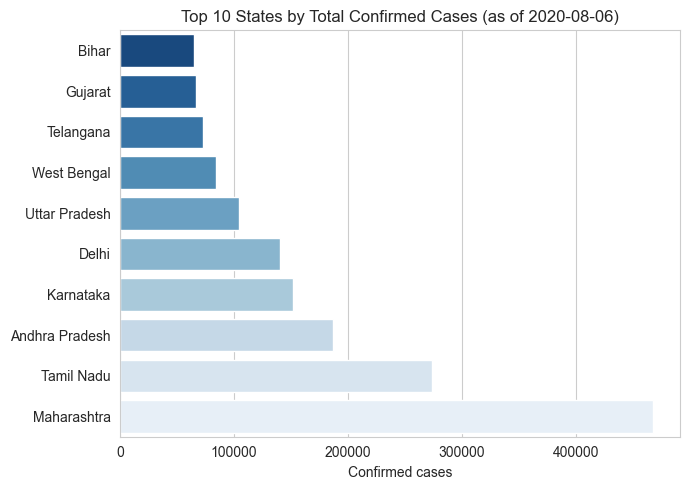

In [16]:
top10 = latest.nlargest(10, "confirmed").sort_values("confirmed")

plt.figure(figsize=(7, 5))
sns.barplot(
    x="confirmed", y="state", data=top10,
    hue="state", palette="Blues_r", legend=False
)
plt.title("Top 10 States by Total Confirmed Cases (as of 2020-08-06)")
plt.xlabel("Confirmed cases")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Figure 4** — Share of national confirmed cases held by the top states.

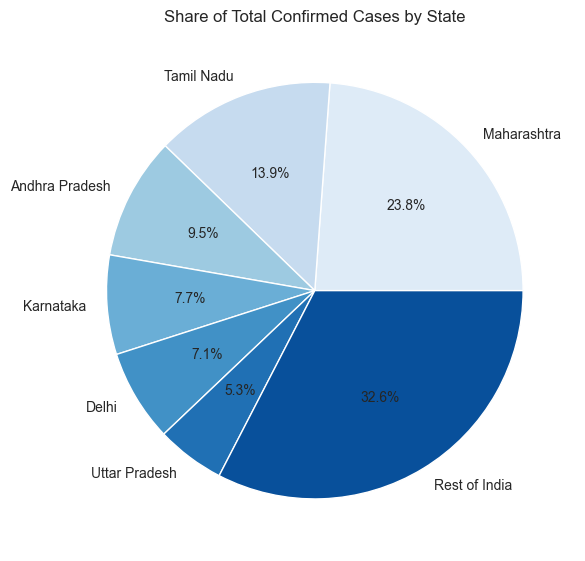

In [17]:
top6 = latest.nlargest(6, "confirmed")
rest = latest["confirmed"].sum() - top6["confirmed"].sum()

pie_labels = list(top6["state"]) + ["Rest of India"]
pie_values = list(top6["confirmed"]) + [rest]

plt.figure(figsize=(6, 6))
plt.pie(
    pie_values, labels=pie_labels, autopct="%1.1f%%",
    colors=sns.color_palette("Blues", len(pie_values))
)
plt.title("Share of Total Confirmed Cases by State")
plt.tight_layout()
plt.show()

> **Finding**
>
> The outbreak was heavily **concentrated, not evenly spread**. Maharashtra alone accounted for
> close to a quarter of all national cases (~4.68 lakh), with **Tamil Nadu, Andhra Pradesh,
> Karnataka, and Delhi** rounding out the top five. Together, the top six states held the clear
> majority of the country's total case load.

**Figure 5** — Confirmed-case growth curves for the top 5 states, over time.

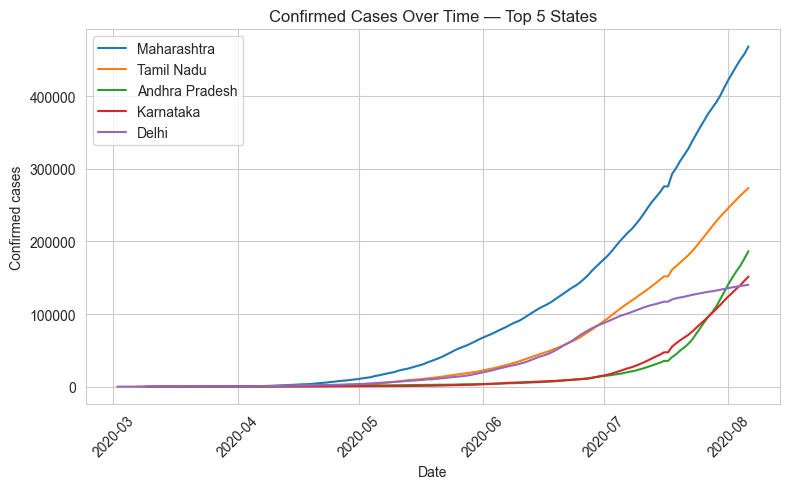

In [18]:
top5_states = latest.nlargest(5, "confirmed")["state"].tolist()

plt.figure(figsize=(8, 5))
for state in top5_states:
    state_data = cases[cases["state"] == state]
    plt.plot(state_data["date"], state_data["confirmed"], label=state)

plt.title("Confirmed Cases Over Time — Top 5 States")
plt.xlabel("Date")
plt.ylabel("Confirmed cases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Recovery and death rates

**Figure 6** — Recovery rate (%) for the ten worst-hit states.

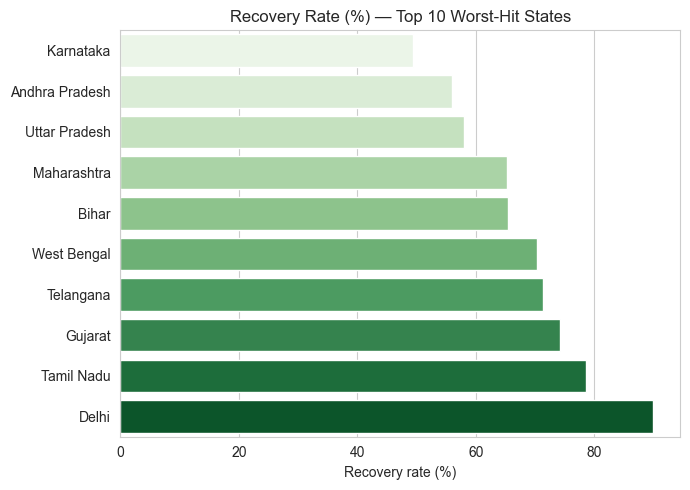

In [19]:
top10_worst = latest.nlargest(10, "confirmed").copy()
top10_worst["recovery_rate"] = (top10_worst["cured"] / top10_worst["confirmed"] * 100).round(2)
top10_worst = top10_worst.sort_values("recovery_rate")

plt.figure(figsize=(7, 5))
sns.barplot(
    x="recovery_rate", y="state", data=top10_worst,
    hue="state", palette="Greens", legend=False
)
plt.title("Recovery Rate (%) — Top 10 Worst-Hit States")
plt.xlabel("Recovery rate (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Figure 7** — National recovery rate over time.

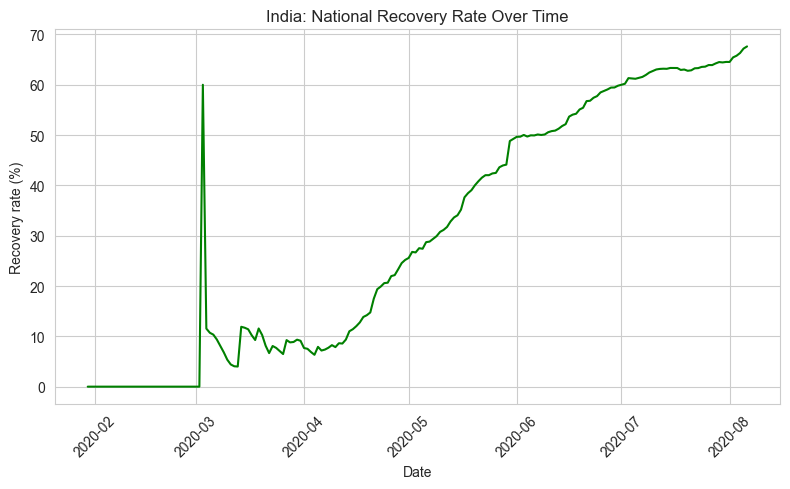

final national recovery rate: 67.62 %


In [20]:
plt.figure(figsize=(8, 5))
plt.plot(national["date"], national["recovery_rate"], color="green")
plt.title("India: National Recovery Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Recovery rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("final national recovery rate:", national["recovery_rate"].iloc[-1], "%")

> **Finding**
>
> Recovery varied a lot state to state. **Delhi** stands out with a recovery rate near **90%** —
> well ahead of every other high-case state — while **Karnataka** was still under **50%**
> recovered at this snapshot, suggesting Karnataka's outbreak was comparatively newer or
> faster-growing relative to how much time had passed for patients to recover. Nationally, the
> recovery rate climbed steadily throughout the window, ending near **68%**.

**Figure 8** — Recovery rate vs death rate by state (bubble size = case count).

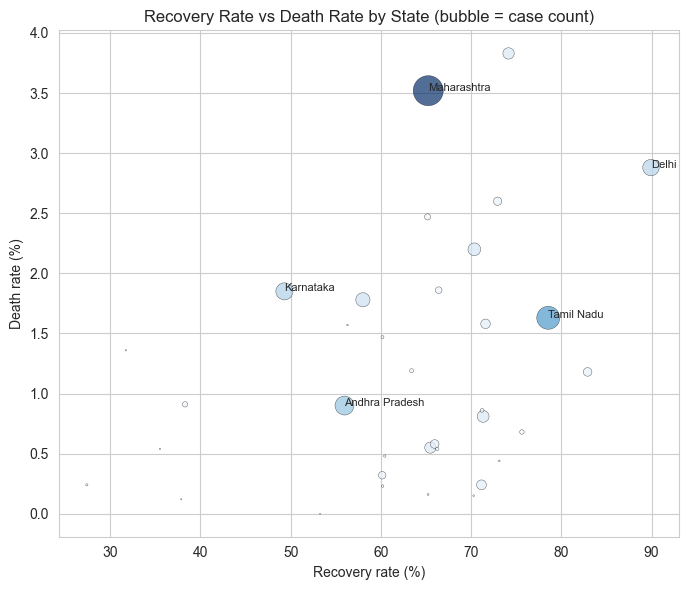

In [21]:
latest_plot = latest.copy()
latest_plot["recovery_rate"] = (latest_plot["cured"] / latest_plot["confirmed"] * 100).round(2)
latest_plot["death_rate"] = (latest_plot["deaths"] / latest_plot["confirmed"] * 100).round(2)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    latest_plot["recovery_rate"], latest_plot["death_rate"],
    s=latest_plot["confirmed"] / 1000,
    c=latest_plot["confirmed"], cmap="Blues", alpha=0.7,
    edgecolors="k", linewidths=0.3
)

# label the top 5 states
for _, row in latest_plot.nlargest(5, "confirmed").iterrows():
    plt.annotate(row["state"], (row["recovery_rate"], row["death_rate"]), fontsize=8)

plt.title("Recovery Rate vs Death Rate by State (bubble = case count)")
plt.xlabel("Recovery rate (%)")
plt.ylabel("Death rate (%)")
plt.tight_layout()
plt.show()

> **Finding**
>
> Among the worst-hit states, **Gujarat** had the highest death rate, at nearly **3.8%** —
> noticeably above the **2.1%** national average — while lower-case states like **Bihar** and
> **Telangana** had death rates under **1%**. This kind of gap is worth digging into further:
> differences in health infrastructure, age demographics, and testing intensity could all be
> contributing factors, though this dataset alone can't tell us which.

### How metrics relate to each other, and how the outbreak evolved month by month

**Figure 9** — Correlation between national COVID-19 metrics.

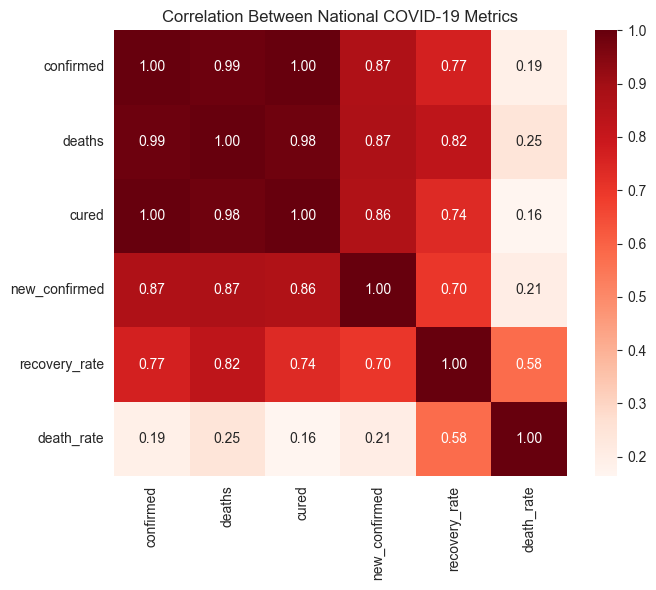

In [22]:
national["new_confirmed"] = national["confirmed"].diff().fillna(0)
national["death_rate"] = (national["deaths"] / national["confirmed"] * 100).round(2)

corr_cols = national[["confirmed", "deaths", "cured", "new_confirmed", "recovery_rate", "death_rate"]]
corr = corr_cols.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="Reds", fmt=".2f")
plt.title("Correlation Between National COVID-19 Metrics")
plt.tight_layout()
plt.show()

**Figure 10** — Spread of daily new cases, by month.

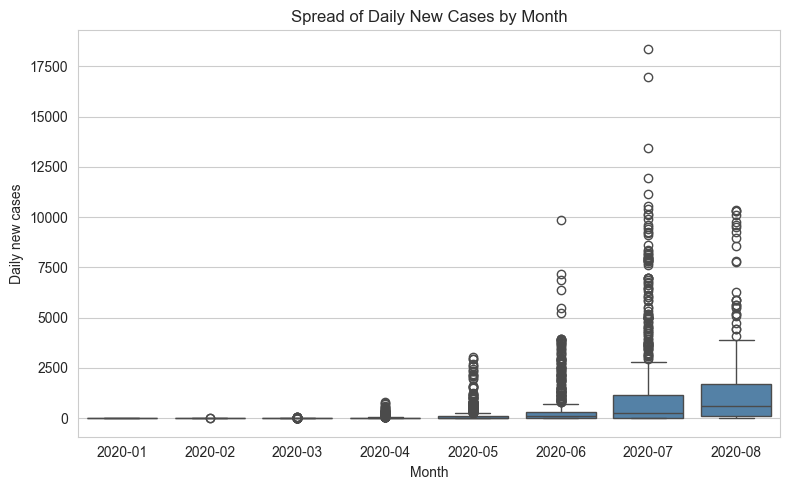

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="month", y="new_cases", data=cases, color="steelblue")
plt.title("Spread of Daily New Cases by Month")
plt.xlabel("Month")
plt.ylabel("Daily new cases")
plt.tight_layout()
plt.show()

> **Finding**
>
> The monthly boxplot makes the acceleration obvious: both the **median** daily case count and its
> **spread** grew every month from February to August 2020, with July and August showing the widest
> range of daily new cases — a visual confirmation that the outbreak's pace, and its day-to-day
> volatility, both increased over the period covered.
>
> The correlation heatmap adds a caution: cumulative `confirmed`, `deaths`, and `cured` are all
> near-perfectly correlated with each other simply because all three only ever go up over time.
> That correlation reflects the passage of time, not a causal relationship.

### The other end of the spectrum, and the vaccination follow-up

**Figure 11** — The ten least-affected states/UTs by confirmed case count.

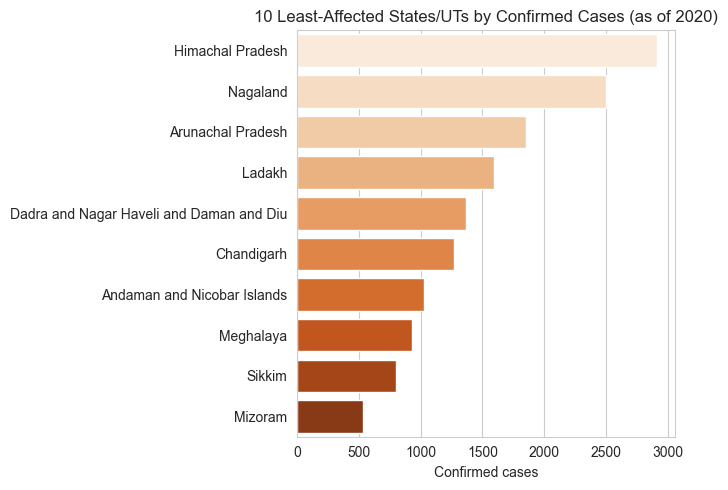

In [24]:
bottom10 = latest.nsmallest(10, "confirmed").sort_values("confirmed", ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(
    x="confirmed", y="state", data=bottom10,
    hue="state", palette="Oranges", legend=False
)
plt.title("10 Least-Affected States/UTs by Confirmed Cases (as of 2020)")
plt.xlabel("Confirmed cases")
plt.ylabel("")
plt.tight_layout()
plt.show()

> **Finding**
>
> Small northeastern states and union territories — **Mizoram, Sikkim, Meghalaya**, and the
> **Andaman & Nicobar Islands** — recorded the fewest cases, each under **1,100** total confirmed
> cases by August 2020, likely reflecting both smaller populations and lower population
> density/connectivity.

**Figure 12** — India's national vaccination progress, 2021–2024 (OWID data).

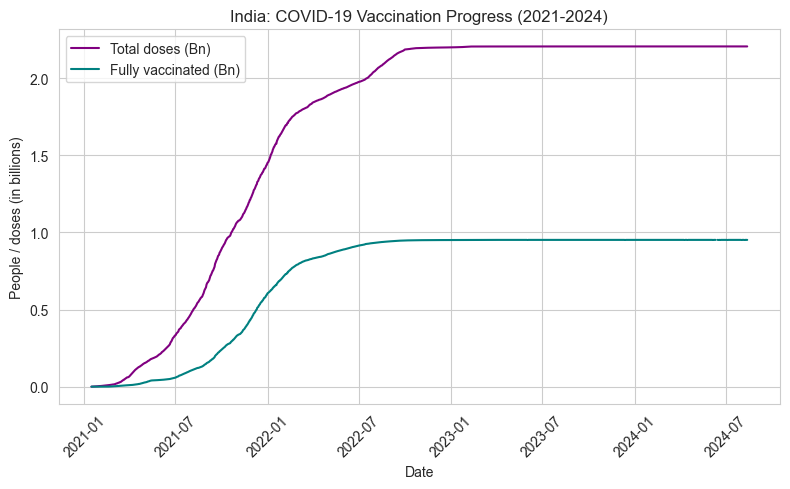

latest total doses:       2,206,868,000
latest fully vaccinated:  951,990,552


In [25]:
vax["date"] = pd.to_datetime(vax["date"])
vax["total_doses_bn"] = vax["total_vaccinations"] / 1e9
vax["fully_vax_bn"] = vax["people_fully_vaccinated"] / 1e9

plt.figure(figsize=(8, 5))
plt.plot(vax["date"], vax["total_doses_bn"], label="Total doses (Bn)", color="purple")
plt.plot(vax["date"], vax["fully_vax_bn"], label="Fully vaccinated (Bn)", color="teal")
plt.title("India: COVID-19 Vaccination Progress (2021-2024)")
plt.xlabel("Date")
plt.ylabel("People / doses (in billions)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("latest total doses:      ", f"{vax['total_vaccinations'].max():,.0f}")
print("latest fully vaccinated: ", f"{vax['people_fully_vaccinated'].max():,.0f}")

> **Finding**
>
> By mid-2024, India had administered over **2.2 billion** vaccine doses and fully vaccinated more
> than **950 million** people — illustrating the scale of the public health response that followed
> the wave captured in this project's case data.

## Step 6 — Summarise

The numbers below are printed from the cleaned data rather than typed in by hand, so the summary
cannot drift out of sync with the dataset.

In [26]:
summary = {
    "states / UTs (after cleaning)": cases["state"].nunique(),
    "days covered": cases["date"].nunique(),
    "first date": cases["date"].min().date(),
    "last date": cases["date"].max().date(),
    "total confirmed": int(national["confirmed"].iloc[-1]),
    "total recovered": int(national["cured"].iloc[-1]),
    "total deaths": int(national["deaths"].iloc[-1]),
    "national recovery rate (%)": national["recovery_rate"].iloc[-1],
    "national death rate (%)": national["death_rate"].iloc[-1],
    "peak daily new cases": int(daily_new["new_cases"].max()),
    "top state by cases": latest.iloc[0]["state"],
}

for k, v in summary.items():
    print(f"{k:32} {v}")

states / UTs (after cleaning)    35
days covered                     186
first date                       2020-01-30
last date                        2020-08-06
total confirmed                  1964536
total recovered                  1328336
total deaths                     40699
national recovery rate (%)       67.62
national death rate (%)          2.07
peak daily new cases             70962
top state by cases               Maharashtra


### Overall summary

- The dataset covers **35 states/UTs** (after cleaning up duplicate name spellings) across
  **186 days**, from **30 January to 6 August 2020**.
- India's first wave was **still accelerating** at the end of this window — confirmed cases were
  growing, and the daily new-case count had not yet peaked.
- The outbreak's impact was **far from uniform** across states: a handful of states carried the
  large majority of the case load, while several smaller states/UTs stayed in the low thousands.
- **Recovery and death rates both varied meaningfully by state**, hinting at real differences in
  healthcare capacity, testing, and demographics worth investigating with additional data.
- The vaccination rollout that followed (2021 onward) reached **over 2 billion doses** administered
  by 2024 — a useful reminder that this case dataset captures only the opening chapter of India's
  COVID-19 response.

### Caveats

This is state-bulletin-sourced data, so it inherits whatever inconsistencies existed in how
individual states reported their numbers (hence the spelling and text-formatted `Death` column
issues fixed in Step 3). Recovery and death rates here are simple ratios of cumulative totals on a
single date, **not adjusted for reporting lag or right-censoring**, so they should be read as
directional trends rather than precise clinical outcome rates.

### Suggestions for further analysis

- Bring in **state population figures** to convert raw case counts into per-capita rates for a
  fairer state-to-state comparison.
- Join **district-level data** (also available in the same source repository) to see which cities,
  not just states, drove the national numbers.
- **Extend the case time series past August 2020** (using a more recent source) to see the full
  shape of India's first and second waves side by side.